In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import reportlab

In [2]:
df = pd.read_csv("Superstore.csv", encoding="latin1")
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

profit_margin = (total_profit/total_sales) * 100

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: 2,297,200.86
Total Profit: 286,397.02
Profit Margin: 12.47%


In [4]:
top_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [5]:
worst_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

profit_margin = (total_profit/total_sales) * 100

loss_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .lt(0)
    .sum()
)

print("Business Insights")
print("-" * 40)

if profit_margin < 15:
    print(f" Profit margin is only {profit_margin:.2f}%. Review pricing and discount strategy.")
else:
    print(f" Healthy profit margin of {profit_margin:.2f}%.")

if loss_customers > 100:
    print(f" {loss_customers} customers generated negative profit.")
else:
    print(f" Only {loss_customers} customers generated losses.")

Business Insights
----------------------------------------
 Profit margin is only 12.47%. Review pricing and discount strategy.
 155 customers generated negative profit.


In [7]:
def discount_band(x):
    if x == 0:
        return "0%"
    elif x <= 0.1:
        return "0-10%"
    elif x <= 0.2:
        return "10-20%"
    elif x <= 0.3:
        return "20-30%"
    else:
        return "30%+"

In [8]:
df["Discount Band"] = df["Discount"].apply(discount_band)

In [9]:
discount_analysis = (
    df.groupby("Discount Band")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
)

discount_analysis["Profit Margin"] = (
    discount_analysis["Profit"]
    / discount_analysis["Sales"]
) * 100

discount_analysis

,Sales,Profit,Profit Margin
Discount Band,,,
0%,1.087908e+06,320987.6032,29.505019
0-10%,5.436935e+04,9029.1770,16.607108
10-20%,7.921529e+05,91756.2975,11.583155
20-30%,1.032267e+05,-10369.2774,-10.045155
30%+,2.595435e+05,-125006.7786,-48.164096


In [10]:
high_discount_margin = discount_analysis.loc[
    "30%+", "Profit Margin"
]

if high_discount_margin < 0:
    print(
        "⚠️ Discounts above 30% are associated with negative profitability."
    )

⚠️ Discounts above 30% are associated with negative profitability.


In [11]:
report = f"""
Executive Business Report
{'=' * 40}

Profit Margin: {profit_margin:.2f}%
Loss-Making Customers: {loss_customers}
High Discount Margin (30%+): {high_discount_margin:.2f}%

Key Findings
1. The company achieved a profit margin of {profit_margin:.2f}%.
2. A total of {loss_customers} customers generated negative profit.
3. Discounts above 30% are associated with negative profitability-

Recommendations
• Review discount policies above 30%.
• Focus on profitable customers rather than sales volume alone.
• Monitor loss-making customers.
• Continue investing in high-performing categories.
{'=' * 40}
"""

print(report)


Executive Business Report

Profit Margin: 12.47%
Loss-Making Customers: 155
High Discount Margin (30%+): -48.16%

Key Findings
1. The company achieved a profit margin of 12.47%.
2. A total of 155 customers generated negative profit.
3. Discounts above 30% are associated with negative profitability-

Recommendations
• Review discount policies above 30%.
• Focus on profitable customers rather than sales volume alone.
• Monitor loss-making customers.
• Continue investing in high-performing categories.



In [12]:
recommendations = []

if profit_margin < 15:
    recommendations.append(
        "Review pricing and discount strategy to improve overall profitability."
    )
if loss_customers > 100:
    recommendations.append(
        "Investigate loss-making customers and review their purchasing patterns."
    )
if high_discount_margin < 0:
    recommendations.append(
        "Reduce discounts above 30% as they are associated with negative profitability."
    )
for rec in recommendations:
    print("•", rec)

• Review pricing and discount strategy to improve overall profitability.
• Investigate loss-making customers and review their purchasing patterns.
• Reduce discounts above 30% as they are associated with negative profitability.


In [13]:
recommendations_text = ""
for rec in recommendations:
    recommendations_text += f"\n• {rec}"

print(recommendations_text)


• Review pricing and discount strategy to improve overall profitability.
• Investigate loss-making customers and review their purchasing patterns.
• Reduce discounts above 30% as they are associated with negative profitability.


In [14]:
report = f"""
EXECUTIVE BUSINESS REPORT
{'=' * 40}

Profit Margin: {profit_margin:.2f}%

Loss-Making Customers: {loss_customers}

High Discount Margin (30%+): {high_discount_margin:.2f}%

KEY FINDINGS

1. The company achieved a profit margin of {profit_margin:.2f}%.

2. A total of {loss_customers} customers generated negative profit.

3. Discounts above 30% are associated with negative profitability.

RECOMMENDATIONS
{recommendations_text}

{'=' * 40}
"""

print(report)


EXECUTIVE BUSINESS REPORT

Profit Margin: 12.47%

Loss-Making Customers: 155

High Discount Margin (30%+): -48.16%

KEY FINDINGS

1. The company achieved a profit margin of 12.47%.

2. A total of 155 customers generated negative profit.

3. Discounts above 30% are associated with negative profitability.

RECOMMENDATIONS

• Review pricing and discount strategy to improve overall profitability.
• Investigate loss-making customers and review their purchasing patterns.
• Reduce discounts above 30% as they are associated with negative profitability.




In [15]:
findings = []
findings.append(
    f"The company achieved a profit margin of {profit_margin:.2f}%."
)
findings.append(
    f"A total of {loss_customers} customers generated negative profit."
)
if high_discount_margin < 0:
    findings.append(
        "Discounts above 30% are associated with negative profitability."
    )

for i, finding in enumerate(findings, start=1):
    print (f"{i}. {findings}")

1. ['The company achieved a profit margin of 12.47%.', 'A total of 155 customers generated negative profit.', 'Discounts above 30% are associated with negative profitability.']
2. ['The company achieved a profit margin of 12.47%.', 'A total of 155 customers generated negative profit.', 'Discounts above 30% are associated with negative profitability.']
3. ['The company achieved a profit margin of 12.47%.', 'A total of 155 customers generated negative profit.', 'Discounts above 30% are associated with negative profitability.']


In [16]:
findings_text = ""

for i, finding in enumerate(findings, start=1):
    findings_text += f"\n{i}. {finding}"

print(findings_text)


1. The company achieved a profit margin of 12.47%.
2. A total of 155 customers generated negative profit.
3. Discounts above 30% are associated with negative profitability.


In [17]:
report = f"""
EXECUTIVE BUSINESS REPORT
{'=' * 40}

Profit Margin: {profit_margin:.2f}%

Loss-Making Customers: {loss_customers}

High Discount Margin (30%+): {high_discount_margin:.2f}%

KEY FINDINGS

{findings_text}

RECOMMENDATIONS
{recommendations_text}

{'=' * 40}
"""

print(report)


EXECUTIVE BUSINESS REPORT

Profit Margin: 12.47%

Loss-Making Customers: 155

High Discount Margin (30%+): -48.16%

KEY FINDINGS


1. The company achieved a profit margin of 12.47%.
2. A total of 155 customers generated negative profit.
3. Discounts above 30% are associated with negative profitability.

RECOMMENDATIONS

• Review pricing and discount strategy to improve overall profitability.
• Investigate loss-making customers and review their purchasing patterns.
• Reduce discounts above 30% as they are associated with negative profitability.




In [18]:
with open("executive_report.txt", "w", encoding="utf-8") as file:
    file.write(report)

In [19]:
findings = []

if profit_margin < 10:
    findings.append(
        f"Profitability is critically low at {profit_margin:.2f}%."
    )
elif profit_margin < 15:
    findings.append(
        f"Profitability is below target at {profit_margin:.2f}%."
    )
else:
    findings.append(
        f"Profitability is healthy at {profit_margin:.2f}%."
    )


if loss_customers > 100:
    findings.append(
        f"{loss_customers} customers generated negative profit, indicating potential customer profitability issues."
    )
else:
    findings.append(
        f"Only {loss_customers} customers generated negative profit."
    )


if high_discount_margin < 0:
    findings.append(
        f"Discounts above 30% resulted in a negative margin of {high_discount_margin:.2f}%."
    )
else:
    findings.append(
        f"High-discount transactions remain profitable with a margin of {high_discount_margin:.2f}%."
    )

In [20]:
recommendations = []

if profit_margin < 15:
    recommendations.append(
        "Review pricing and discount policies to improve overall profitability."
    )

if loss_customers > 100:
    recommendations.append(
        "Perform a detailed analysis of loss-making customers."
    )

if high_discount_margin < 0:
    recommendations.append(
        "Reduce or redesign discount campaigns above 30%."
    )

if profit_margin >= 15 and loss_customers < 100:
    recommendations.append(
        "Maintain current commercial strategy and continue monitoring performance."
    )

In [21]:
findings_text = ""

for i, finding in enumerate(findings, start=1):
    findings_text += f"\n{i}. {finding}"


In [22]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

In [23]:
prompt = f"""
You are a Senior Business Analyst.

Analyze the following business metrics:

Profit Margin: {profit_margin:.2f}%

Loss-Making Customers: {loss_customers}

High Discount Margin: {high_discount_margin:.2f}%

Generate:

1. Executive Summary

2. Key Findings

3. Recommendations

Write professionally.
"""

print(prompt)


You are a Senior Business Analyst.

Analyze the following business metrics:

Profit Margin: 12.47%

Loss-Making Customers: 155

High Discount Margin: -48.16%

Generate:

1. Executive Summary

2. Key Findings

3. Recommendations

Write professionally.



In [24]:
top_customer = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

In [25]:
top_customer_name = top_customer.index[0]
top_customer_profit = top_customer.iloc[0]

print(top_customer_name, top_customer_profit)

Tamara Chand 8981.323900000001


In [26]:
worst_customer = (
    df.groupby("Customer Name")["Profit"]
            .sum()
            .sort_values()
            .head(1)
        )
    
worst_customer_name = worst_customer.index[0]
worst_customer_profit = worst_customer.iloc[0]

print(worst_customer_name, worst_customer_profit)

Cindy Stewart -6626.389499999999


In [27]:
top_category = (
        df.groupby("Category")["Profit"]
        .sum()
        .sort_values(ascending=False)
        .head(1)
        )

top_category_name = top_category.index[0]
top_category_profit = top_category.iloc[0]

print(top_category_name, top_category_profit)

Technology 145454.9481


In [28]:
top_region = ( df.groupby("Region")["Sales"]
              .sum() .sort_values(ascending=False)
              .head(1)
             ) 
top_region_name = top_region.index[0]
top_region_sales = top_region.iloc[0] 

print(top_region_name, top_region_sales)

West 725457.8245


In [29]:
prompt = f"""
You are a Senior Business Analyst.

Analyze the following company performance metrics.

COMPANY PERFORMANCE

Profit Margin: {profit_margin:.2f}%

Loss-Making Customers: {loss_customers}

High Discount Margin (30%+): {high_discount_margin:.2f}%


CUSTOMER ANALYSIS

Top Customer: {top_customer_name}

Customer Profit: {top_customer_profit:.2f}

Worst Customer: {worst_customer_name}

Customer Profit: {worst_customer_profit:.2f}


PRODUCT ANALYSIS

Most Profitable Category: {top_category_name}

Category Profit: {top_category_profit:.2f}


REGIONAL ANALYSIS

Top Region: {top_region_name}

Region Sales: {top_region_sales:.2f}


Generate:

1. Executive Summary

2. Key Findings

3. Business Risks

4. Strategic Recommendations

Write in a professional business style.
"""

print(prompt)


You are a Senior Business Analyst.

Analyze the following company performance metrics.

COMPANY PERFORMANCE

Profit Margin: 12.47%

Loss-Making Customers: 155

High Discount Margin (30%+): -48.16%


CUSTOMER ANALYSIS

Top Customer: Tamara Chand

Customer Profit: 8981.32

Worst Customer: Cindy Stewart

Customer Profit: -6626.39


PRODUCT ANALYSIS

Most Profitable Category: Technology

Category Profit: 145454.95


REGIONAL ANALYSIS

Top Region: West

Region Sales: 725457.82


Generate:

1. Executive Summary

2. Key Findings

3. Business Risks

4. Strategic Recommendations

Write in a professional business style.



In [30]:
top_5_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

worst_5_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values()
    .head(5)
)

top_5_customers_text = top_5_customers.to_string()

worst_5_customers_text = worst_5_customers.to_string()

In [31]:
prompt = f"""
You are a Senior Business Analyst.

Analyze the following company performance metrics.

Profit Margin: {profit_margin:.2f}%

Loss-Making Customers: {loss_customers}

High Discount Margin (30%+): {high_discount_margin:.2f}%


Top 5 Customers

{top_5_customers_text}


Worst 5 Customers

{worst_5_customers_text}


Most Profitable Category:
{top_category_name}

Category Profit:
{top_category_profit:.2f}


Top Region:
{top_region_name}

Region Sales:
{top_region_sales:.2f}


Generate:

1. Executive Summary

2. Key Findings

3. Business Risks

4. Strategic Recommendations

Write professionally.
"""

print(prompt)


You are a Senior Business Analyst.

Analyze the following company performance metrics.

Profit Margin: 12.47%

Loss-Making Customers: 155

High Discount Margin (30%+): -48.16%


Top 5 Customers

Customer Name
Tamara Chand     8981.3239
Raymond Buch     6976.0959
Sanjit Chand     5757.4119
Hunter Lopez     5622.4292
Adrian Barton    5444.8055


Worst 5 Customers

Customer Name
Cindy Stewart    -6626.3895
Grant Thornton   -4108.6589
Luke Foster      -3583.9770
Sharelle Roach   -3333.9144
Henry Goldwyn    -2797.9635


Most Profitable Category:
Technology

Category Profit:
145454.95


Top Region:
West

Region Sales:
725457.82


Generate:

1. Executive Summary

2. Key Findings

3. Business Risks

4. Strategic Recommendations

Write professionally.



In [32]:
recommendations = []

if profit_margin < 10:
    recommendations.append(
        f"Profitability is critically low ({profit_margin:.2f}%). Immediate review of pricing and discount policies is recommended."
    )

elif profit_margin < 15:
    recommendations.append(
        f"Profitability is below target ({profit_margin:.2f}%). Review pricing strategy and focus on higher-margin products."
    )

else:
    recommendations.append(
        f"Profitability is healthy ({profit_margin:.2f}%). Maintain current pricing strategy."
    )

In [33]:
recommendations = []

if loss_customers > 150:
    recommendations.append(
        f"{loss_customers} customers generated negative profit. Immediate review is recommended."
    )

elif loss_customers > 50:
    recommendations.append(
        f"{loss_customers} customers generated negative profit, indicating potential customer profitability issues."
    )

else:
    recommendations.append(
        f"Only {loss_customers} customers generated negative profit."
    )

print(recommendations)

['155 customers generated negative profit. Immediate review is recommended.']


In [34]:
def generate_profit_recommendation(profit_margin):

    if profit_margin < 10:
        return (
            f"Profitability is critically low ({profit_margin:.2f}%). "
            "Immediate review of pricing and discount policies is recommended."
        )

    elif profit_margin < 15:
        return (
            f"Profitability is below target ({profit_margin:.2f}%). "
            "Review pricing strategy and focus on higher-margin products."
        )

    else:
        return (
            f"Profitability is healthy ({profit_margin:.2f}%). "
            "Maintain current pricing strategy."
        )

In [35]:
profit_recommendation = generate_profit_recommendation(
    profit_margin
)

print(profit_recommendation)

Profitability is below target (12.47%). Review pricing strategy and focus on higher-margin products.


In [36]:
def generate_customer_recommendation(loss_customers):

    if loss_customers > 150:
        return (
            f"{loss_customers} customers generated negative profit. "
            "Immediate review is recommended."
        )

    elif loss_customers > 50:
        return (
            f"{loss_customers} customers generated negative profit, "
            "indicating potential customer profitability issues."
        )

    else:
        return (
            f"Only {loss_customers} customers generated negative profit."
        )

In [37]:
customer_recommendation = generate_customer_recommendation(
    loss_customers
)

print(customer_recommendation)

155 customers generated negative profit. Immediate review is recommended.


In [38]:
def generate_discount_recommendation(high_discount_margin):

    if high_discount_margin < 0:
        return (
            f"Discounts above 30% resulted in a negative margin "
            f"of {high_discount_margin:.2f}%. Review discount policies."
        )

    else:
        return (
            f"High-discount transactions remain profitable "
            f"with a margin of {high_discount_margin:.2f}%."
        )

In [39]:
discount_recommendation = generate_discount_recommendation(
    high_discount_margin
)

print(discount_recommendation)

Discounts above 30% resulted in a negative margin of -48.16%. Review discount policies.


In [40]:
def generate_executive_summary(
    profit_margin,
    loss_customers,
    high_discount_margin
):

    profit_text = generate_profit_recommendation(
        profit_margin
    )

    customer_text = generate_customer_recommendation(
        loss_customers
    )

    discount_text = generate_discount_recommendation(
        high_discount_margin
    )

    summary = f"""

{profit_text}

{customer_text}

{discount_text}
"""

    return summary

In [41]:
summary = generate_executive_summary(
    profit_margin,
    loss_customers,
    high_discount_margin
)

print(summary)



Profitability is below target (12.47%). Review pricing strategy and focus on higher-margin products.

155 customers generated negative profit. Immediate review is recommended.

Discounts above 30% resulted in a negative margin of -48.16%. Review discount policies.



In [42]:
def generate_business_prompt():

    prompt = f"""
You are a Senior Business Analyst.

Analyze the following company performance metrics.

COMPANY PERFORMANCE

Profit Margin: {profit_margin:.2f}%

Loss-Making Customers: {loss_customers}

High Discount Margin (30%+): {high_discount_margin:.2f}%


CUSTOMER ANALYSIS

Top Customer: {top_customer_name}

Customer Profit: {top_customer_profit:.2f}

Worst Customer: {worst_customer_name}

Customer Profit: {worst_customer_profit:.2f}


PRODUCT ANALYSIS

Most Profitable Category: {top_category_name}

Category Profit: {top_category_profit:.2f}


REGIONAL ANALYSIS

Top Region: {top_region_name}

Region Sales: {top_region_sales:.2f}


TOP 5 CUSTOMERS

{top_5_customers_text}


WORST 5 CUSTOMERS

{worst_5_customers_text}


Generate:

1. Executive Summary

2. Key Findings

3. Business Risks

4. Strategic Recommendations

Write in a professional business style.
"""

    return prompt

In [43]:
business_prompt = generate_business_prompt()

print(business_prompt)


You are a Senior Business Analyst.

Analyze the following company performance metrics.

COMPANY PERFORMANCE

Profit Margin: 12.47%

Loss-Making Customers: 155

High Discount Margin (30%+): -48.16%


CUSTOMER ANALYSIS

Top Customer: Tamara Chand

Customer Profit: 8981.32

Worst Customer: Cindy Stewart

Customer Profit: -6626.39


PRODUCT ANALYSIS

Most Profitable Category: Technology

Category Profit: 145454.95


REGIONAL ANALYSIS

Top Region: West

Region Sales: 725457.82


TOP 5 CUSTOMERS

Customer Name
Tamara Chand     8981.3239
Raymond Buch     6976.0959
Sanjit Chand     5757.4119
Hunter Lopez     5622.4292
Adrian Barton    5444.8055


WORST 5 CUSTOMERS

Customer Name
Cindy Stewart    -6626.3895
Grant Thornton   -4108.6589
Luke Foster      -3583.9770
Sharelle Roach   -3333.9144
Henry Goldwyn    -2797.9635


Generate:

1. Executive Summary

2. Key Findings

3. Business Risks

4. Strategic Recommendations

Write in a professional business style.



In [44]:
def generate_ai_report():

    summary = generate_executive_summary(
        profit_margin,
        loss_customers,
        high_discount_margin
    )

    report = f"""
AI BUSINESS REPORT

{summary}

Top Customer:
{top_customer_name}
({top_customer_profit:.2f})

Worst Customer:
{worst_customer_name}
({worst_customer_profit:.2f})

Most Profitable Category:
{top_category_name}
({top_category_profit:.2f})

Top Region:
{top_region_name}
({top_region_sales:.2f})
"""

    return report

In [45]:
ai_report = generate_ai_report()

print(ai_report)


AI BUSINESS REPORT



Profitability is below target (12.47%). Review pricing strategy and focus on higher-margin products.

155 customers generated negative profit. Immediate review is recommended.

Discounts above 30% resulted in a negative margin of -48.16%. Review discount policies.


Top Customer:
Tamara Chand
(8981.32)

Worst Customer:
Cindy Stewart
(-6626.39)

Most Profitable Category:
Technology
(145454.95)

Top Region:
West
(725457.82)



In [46]:
metrics = {
    "profit_margin": profit_margin,
    "loss_customers": loss_customers,
    "high_discount_margin": high_discount_margin
}

In [47]:
final_recommendations = []

if profit_margin < 15:
    final_recommendations.append(
        "Review pricing and discount policies to improve overall profitability."
    )

if loss_customers > 100:
    final_recommendations.append(
        "Perform a detailed analysis of loss-making customers."
    )

if high_discount_margin < 0:
    final_recommendations.append(
        "Reduce or redesign discount campaigns above 30%."
    )

In [48]:
pdf = SimpleDocTemplate(
    "Executive_Business_Report.pdf"
)

styles = getSampleStyleSheet()

content = []

# Generate report
ai_report = generate_ai_report()

# Title
content.append(
    Paragraph(
        "Executive Business Report",
        styles["Title"]
    )
)

content.append(Spacer(1, 12))

# KPI Section
content.append(
    Paragraph(
        f"Profit Margin: {profit_margin:.2f}%",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Loss-Making Customers: {loss_customers}",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"High Discount Margin (30%+): {high_discount_margin:.2f}%",
        styles["Normal"]
    )
)

content.append(Spacer(1, 12))

# Executive Summary
content.append(
    Paragraph(
        "Executive Summary",
        styles["Heading2"]
    )
)

summary = generate_executive_summary(
    profit_margin,
    loss_customers,
    high_discount_margin
)

for line in summary.strip().split("\n"):
    if line.strip():
        content.append(
            Paragraph(
                line,
                styles["Normal"]
            )
        )

content.append(Spacer(1, 12))

# Business Overview
content.append(
    Paragraph(
        "Business Overview",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        f"Top Customer: {top_customer_name} ({top_customer_profit:.2f})",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Worst Customer: {worst_customer_name} ({worst_customer_profit:.2f})",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Most Profitable Category: {top_category_name} ({top_category_profit:.2f})",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Top Region: {top_region_name} ({top_region_sales:.2f})",
        styles["Normal"]
    )
)

content.append(Spacer(1, 12))

# Recommendations
content.append(
    Paragraph(
        "Recommendations",
        styles["Heading2"]
    )
)

for rec in final_recommendations:
    content.append(
        Paragraph(
            f"• {rec}",
            styles["Normal"]
        )
    )

pdf.build(content)

print("PDF created successfully!")

PDF created successfully!


In [49]:
def generate_ai_insights (
    profit_margin,
    loss_customers,
    high_discount_margin,
    top_category_name,
    top_region_name):

    insights = []
    
    if profit_margin < 15:
        insights.append(
        f"Profitability remains below target at {profit_margin:.2f}%, indicating opportunities to improve margins."
    )
    else:
        insights.append (
              f"Profitability is healthy ({profit_margin:.2f}%). "
            "Maintain current pricing strategy."
        )

    if high_discount_margin < 0:
        insights.append(
        f"High-discount transactions generated a margin of {high_discount_margin:.2f}%, indicating that aggressive discounting may be reducing profitability."
    )
    else:
        insights.append(
        f"High-discount transactions generated a positive margin of {high_discount_margin:.2f}%, suggesting that discount strategies are contributing positively to profitability."
    )

    if loss_customers > 100:
        insights.append (
    f"A total of {loss_customers} customers generated negative profit, suggesting a need for customer profitability segmentation."
    )
    else:
        insights.append (
        f"Only {loss_customers} customers generated negative profit, indicating a relatively healthy customer base."
    )

    insights.append(
    f"{top_category_name} is currently the most profitable category and represents a potential growth opportunity."
    )

    insights.append(
    f"{top_region_name} is the top-performing region and may provide best practices that can be replicated across other regions."
    )

    return insights

In [50]:
ai_insights = generate_ai_insights(
    profit_margin,
    loss_customers,
    high_discount_margin,
    top_category_name,
    top_region_name
)

for insight in ai_insights:
    print(insight)

Profitability remains below target at 12.47%, indicating opportunities to improve margins.
High-discount transactions generated a margin of -48.16%, indicating that aggressive discounting may be reducing profitability.
A total of 155 customers generated negative profit, suggesting a need for customer profitability segmentation.
Technology is currently the most profitable category and represents a potential growth opportunity.
West is the top-performing region and may provide best practices that can be replicated across other regions.


<h1>Machine Learning</h>

In [51]:
from sklearn.model_selection import train_test_split

X = df[["Sales","Discount","Quantity"]]

y = df ["Profit"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7995, 3)
(1999, 3)
(7995,)
(1999,)


In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression ()

model.fit(X_train, y_train)

LinearRegression()

In [55]:
predictions = model.predict(X_test)

print(predictions[:5])

[107.87113002 -15.809824    26.1247804    2.27606799  12.58883468]


In [56]:
print(y_test.iloc[:5])

3125    21.1428
1441    11.4600
4510    17.1580
39     -15.1470
4509    -6.4233
Name: Profit, dtype: float64


In [57]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error (y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 69.77


In [58]:
print(df["Profit"].describe())

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64


In [59]:
pd.get_dummies(df["Category"])

,Furniture,Office Supplies,Technology
0,True,False,False
1,True,False,False
2,False,True,False
3,True,False,False
4,False,True,False
...,...,...,...
9989,True,False,False
9990,True,False,False
9991,False,False,True
9992,False,True,False


<h1>Inclusão de Categoria</h>

In [60]:
category_dummies = pd.get_dummies(
    df["Category"],
    dtype=int
)

In [61]:
X_v2 = pd.concat(
    [
        df[["Sales","Discount","Quantity"]],
        category_dummies
    ],
    axis=1
)

In [62]:
print(X_v2.head())

      Sales  Discount  Quantity  Furniture  Office Supplies  Technology
0  261.9600      0.00         2          1                0           0
1  731.9400      0.00         3          1                0           0
2   14.6200      0.00         2          0                1           0
3  957.5775      0.45         5          1                0           0
4   22.3680      0.20         2          0                1           0


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X_v2,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
model_v2 = LinearRegression()

model_v2.fit(X_train,y_train)

LinearRegression()

In [65]:
predictions_v2 = model_v2.predict(X_test)

In [66]:
mae_v2 = mean_absolute_error(
    y_test,
    predictions_v2
)
print(f"New Mae: {mae_v2:.2f}")

New Mae: 69.54


<h1>Inclusão de Sub Categorias</h1>

In [67]:
print(df["Sub-Category"].unique())

['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [68]:
subcategory_dummies = pd.get_dummies(
    df["Sub-Category"],
    dtype=int
)
print(subcategory_dummies.shape)

(9994, 17)


In [69]:
X_v3 = pd.concat(
    [
        df[["Sales", "Discount", "Quantity"]],
        subcategory_dummies
    ],
    axis=1
)
print(X_v3.shape)

(9994, 20)


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X_v3,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
model_v3 = LinearRegression()

model_v3.fit(X_train, y_train)

LinearRegression()

In [72]:
predictions_v3 = model_v3.predict(X_test)

In [73]:
mae_v3 = mean_absolute_error(
    y_test,
    predictions_v3
)

print(f"MAE V3: {mae_v3:.2f}")

MAE V3: 67.73


<h1>Adicionar Random Forest</h1>

In [74]:
from sklearn.ensemble import RandomForestRegressor

In [75]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [76]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [77]:
rf_predictions = rf_model.predict(X_test)

In [78]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

print(f"Random Forest MAE: {rf_mae:.2f}")

Random Forest MAE: 24.41


In [79]:
feature_importance = pd.DataFrame({
    "Feature": X_v3.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

        Feature  Importance
0         Sales    0.756521
1      Discount    0.175142
2      Quantity    0.017516
6       Binders    0.013028
9       Copiers    0.010652
14     Machines    0.006958
18     Supplies    0.005649
19       Tables    0.003644
17      Storage    0.003435
3   Accessories    0.001371


<h1>Inclusão do Segmento</h1>

In [80]:
segment_dummies = pd.get_dummies(
    df["Segment"],
    dtype=int
)
print(segment_dummies.head())

   Consumer  Corporate  Home Office
0         1          0            0
1         1          0            0
2         0          1            0
3         1          0            0
4         1          0            0


In [81]:
X_v4 = pd.concat(
    [
        df[["Sales", "Discount", "Quantity"]],
        subcategory_dummies,
        segment_dummies
    ],
    axis=1
)

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X_v4,
    y,
    test_size=0.2,
    random_state=42
)

In [83]:
rf_model_v4 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model_v4.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [84]:
predictions_v4 = rf_model_v4.predict(X_test)

In [85]:
mae_v4 = mean_absolute_error(
    y_test,
    predictions_v4
)

print(f"MAE V4: {mae_v4:.2f}")

MAE V4: 24.54


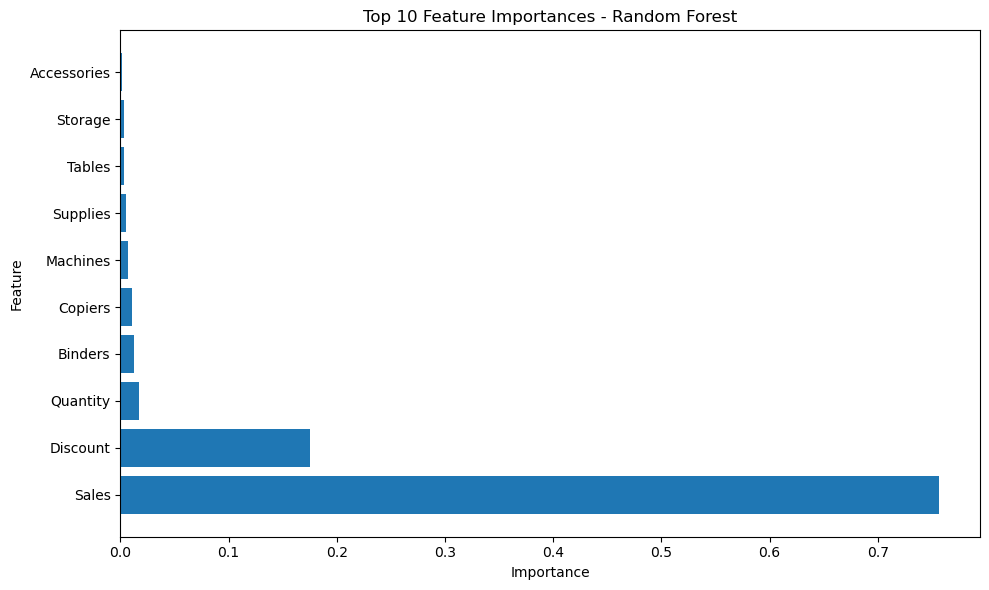

In [86]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()

plt.show()

In [87]:
print(X_v3.columns.tolist())

['Sales', 'Discount', 'Quantity', 'Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']


In [88]:
new_sale = pd.DataFrame({
    "Sales": [1000],
    "Discount": [0.20],
    "Quantity": [5],
    "Accessories": [0],
    "Appliances": [0],
    "Art": [0],
    "Binders": [0],
    "Bookcases": [0],
    "Chairs": [0],
    "Copiers": [0],
    "Envelopes": [0],
    "Fasteners": [0],
    "Furnishings": [0],
    "Labels": [0],
    "Machines": [0],
    "Paper": [0],
    "Phones": [1],
    "Storage": [0],
    "Supplies": [0],
    "Tables": [0]
})

In [89]:
predicted_profit = rf_model.predict(new_sale)

print(f"Predicted Profit: €{predicted_profit[0]:.2f}")

Predicted Profit: €108.20


In [90]:
pdf = SimpleDocTemplate(
    "Executive_Business_Report.pdf"
)

styles = getSampleStyleSheet()

content = []

# Generate report
ai_report = generate_ai_report()

# Title
content.append(
    Paragraph(
        "Executive Business Report",
        styles["Title"]
    )
)

content.append(Spacer(1, 12))

# KPI Section
content.append(
    Paragraph(
        f"Profit Margin: {profit_margin:.2f}%",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Loss-Making Customers: {loss_customers}",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"High Discount Margin (30%+): {high_discount_margin:.2f}%",
        styles["Normal"]
    )
)

content.append(Spacer(1, 12))

# Executive Summary
content.append(
    Paragraph(
        "Executive Summary",
        styles["Heading2"]
    )
)

summary = generate_executive_summary(
    profit_margin,
    loss_customers,
    high_discount_margin
)

for line in summary.strip().split("\n"):
    if line.strip():
        content.append(
            Paragraph(
                line,
                styles["Normal"]
            )
        )

content.append(Spacer(1, 12))

# Business Overview
content.append(
    Paragraph(
        "Business Overview",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        f"Top Customer: {top_customer_name} ({top_customer_profit:.2f})",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Worst Customer: {worst_customer_name} ({worst_customer_profit:.2f})",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Most Profitable Category: {top_category_name} ({top_category_profit:.2f})",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Top Region: {top_region_name} ({top_region_sales:.2f})",
        styles["Normal"]
    )
)

content.append(Spacer(1, 12))

# AI Business Insights

content.append(
    Paragraph(
        "AI Business Insights",
        styles["Heading2"]
    )
)

ai_insights = generate_ai_insights(
    profit_margin,
    loss_customers,
    high_discount_margin,
    top_category_name,
    top_region_name
)

for insight in ai_insights:
    content.append(
        Paragraph(
            f"• {insight}",
            styles["Normal"]
        )
    )

content.append(Spacer(1, 12))

# Machine Learning Analysis

content.append(
    Paragraph(
        "Machine Learning Analysis",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        "Several machine learning models were tested to predict profit.",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        "Linear Regression MAE: 69.77",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        "Linear Regression + Sub-Category MAE: 67.73",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        "Random Forest MAE: 24.41",
        styles["Normal"]
    )
)

content.append(Spacer(1, 6))

content.append(
    Paragraph(
        "Key Findings",
        styles["Heading3"]
    )
)

content.append(
    Paragraph(
        "• Random Forest reduced prediction error by approximately 65% compared to the baseline model.",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        "• Sales was the most important predictor of profitability.",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        "• Discount was the second most important predictor.",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        "• Customer Segment did not provide meaningful improvement to model performance.",
        styles["Normal"]
    )
)

content.append(Spacer(1, 12))

# Recommendations
content.append(
    Paragraph(
        "Recommendations",
        styles["Heading2"]
    )
)

for rec in final_recommendations:
    content.append(
        Paragraph(
            f"• {rec}",
            styles["Normal"]
        )
    )

pdf.build(content)

print("PDF created successfully!")

PDF created successfully!
